# Inpatient Readmission Phase 2

> **Builds on:** Phase 1 baseline (`03a_inpatient_baseline_modeling.ipynb`), which established 
> that clinical complexity features predict readmission well at patient level 
> (ROC-AUC 0.948). Phase 2 reframes the problem at visit level and introduces 
> ensemble models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve, f1_score
)
from xgboost import XGBClassifier
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
gt_ip = pd.read_csv('ehn-gt-cleaned-inpatient-20251223000.csv')
gt_ip['admitdate']     = pd.to_datetime(gt_ip['admitdate'])
gt_ip['dischargedate'] = pd.to_datetime(gt_ip['dischargedate'])
gt_ip['los_days']      = (gt_ip['dischargedate'] - gt_ip['admitdate']).dt.days.clip(lower=0)

charlson = pd.read_csv('charlson_scores.csv')

print('Visits:', len(gt_ip))
print('Patients:', gt_ip['deid_personid'].nunique())
print('Readmission rate:', gt_ip['readmission'].mean().round(3))

Visits: 24206
Patients: 16991
Readmission rate: 0.075


## 2. Feature Engineering — Visit Level

Two new temporal features are created (hypothesized to be strong readmission predictors):
- `n_prior_visits` : number of prior hospitalizations for this patient
- `days_since_last_visit` : days between previous discharge and current 
  admission (-1 for first visit)

These features were not available in Phase 1 (patient-level aggregation 
collapsed this information)

In [3]:
# --- 2. Feature Engineering — Visit Level ---

# Sort by patient and date
gt_ip = gt_ip.sort_values(['deid_personid', 'admitdate']).reset_index(drop=True)

# Prior visits count
gt_ip['n_prior_visits'] = (
    gt_ip.groupby('deid_personid').cumcount()
)

# Days since last visit
gt_ip['prev_dischargedate'] = (
    gt_ip.groupby('deid_personid')['dischargedate'].shift(1) #discharge date of previous visit
)
gt_ip['days_since_last_visit'] = (
    (gt_ip['admitdate'] - gt_ip['prev_dischargedate']).dt.days
).fillna(-1)  #-1 = first visit (no prior discharge date)

# Merge Charlson index
gt_ip = gt_ip.merge(charlson, on='deid_personid', how='left')
gt_ip['comorbidity_score'] = gt_ip['comorbidity_score'].fillna(0).astype(int)

print(gt_ip[['n_prior_visits', 'days_since_last_visit', 'comorbidity_score']].describe())

       n_prior_visits  days_since_last_visit  comorbidity_score
count     24,206.0000            24,206.0000        24,206.0000
mean           0.5872                12.7721             0.1807
std            1.3393                41.6091             0.6852
min            0.0000               -94.0000             0.0000
25%            0.0000                -1.0000             0.0000
50%            0.0000                -1.0000             0.0000
75%            1.0000                 0.0000             0.0000
max           23.0000               349.0000             8.0000


In [4]:
# Data quality check (Overlapping admissions)

# Negative values (excluding -1) indicate a new admission before 
# the previous one was discharged (duplicate claims or overlapping stays)

mask = (gt_ip['days_since_last_visit'] < -1)
print(gt_ip[mask][['deid_personid', 'admitdate', 'dischargedate', 
                     'prev_dischargedate', 'days_since_last_visit']].head(10))

                        deid_personid  admitdate dischargedate  \
134  017a98693bf33487878d68c5edc64206 2024-06-10    2024-06-13   
279  02c29bdb6169a4987659b6e3463da30d 2024-02-29    2024-03-07   
441  044e3b37d9b3f8d77e485cb21487fea3 2024-06-05    2024-06-08   
468  049b6ebdc85919f5da670725a8a03714 2024-10-17    2024-10-29   
713  0713846fcd3e2ffdc5fd22d019e54b44 2024-06-26    2024-07-06   
742  0753fb3519597ed3a94f47da11870762 2024-10-07    2024-10-08   
824  07e00e5c9d5d7593d7073807f740a665 2024-04-18    2024-04-29   
828  07e00e5c9d5d7593d7073807f740a665 2024-11-02    2024-11-10   
853  08261c6fc65e1166a89dd8669c921e5b 2024-04-21    2024-04-27   
856  08261c6fc65e1166a89dd8669c921e5b 2024-06-10    2024-06-12   

    prev_dischargedate  days_since_last_visit  
134         2024-06-13                -3.0000  
279         2024-03-07                -7.0000  
441         2024-06-08                -3.0000  
468         2024-10-29               -12.0000  
713         2024-07-06           

In [5]:
print(f'Visits with overlapping dates: {mask.sum()}')

Visits with overlapping dates: 121


In [6]:
# Resolved by keeping the highest-cost claim per admission (same patient, 
# same admit/discharge dates) 
# These represent multiple billing records for a single hospitalization, 
# not separate visits

gt_ip = (
    gt_ip
    .sort_values('cost', ascending=False)
    .drop_duplicates(subset=['deid_personid', 'admitdate', 'dischargedate'])
    .sort_values(['deid_personid', 'admitdate'])
    .reset_index(drop=True)
)

#print('Visits after deduplicate:', len(gt_ip))
#print('Readmission rate after deduplicate:', gt_ip['readmission'].mean().round(3))

In [7]:
# Recalculate temporal features on clean dataset
gt_ip = gt_ip.sort_values(['deid_personid', 'admitdate']).reset_index(drop=True)

gt_ip['n_prior_visits'] = gt_ip.groupby('deid_personid').cumcount()

gt_ip['prev_dischargedate'] = gt_ip.groupby('deid_personid')['dischargedate'].shift(1)
gt_ip['days_since_last_visit'] = (
    (gt_ip['admitdate'] - gt_ip['prev_dischargedate']).dt.days
).fillna(-1).clip(lower=-1)

print(gt_ip[['n_prior_visits', 'days_since_last_visit']].describe())

       n_prior_visits  days_since_last_visit
count     24,082.0000            24,082.0000
mean           0.5774                12.8735
std            1.3276                41.6847
min            0.0000                -1.0000
25%            0.0000                -1.0000
50%            0.0000                -1.0000
75%            1.0000                 0.0000
max           23.0000               349.0000


In [8]:
# Check negative days (excluding -1)
print((gt_ip['days_since_last_visit'] < -1).sum())

0


In [9]:
# --- 3. Feature Sets & Label ---
numeric_fts = [
    'los_days',
    'n_prior_visits',
    'days_since_last_visit',
    'comorbidity_score',
]

categorical_fts = [
    'planpayer',
    'dischargedisposition',
    'servicing_specialty',
    'icddescription',
]

all_features = numeric_fts + categorical_fts

X = gt_ip[all_features].copy()
y = gt_ip['readmission'].copy()

# --- 4. Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = 42,
    stratify = y #7.5% readm rate for split/train set
)

In [10]:
# --- 5. Preprocessing Pipeline ---
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_fts),
    ('num', 'passthrough', numeric_fts),
])

# --- 6. Logistic Regression (comparison with Phase 1 baseline patient-level) ---
lr = Pipeline([
    ('prep', preprocess),
    ('clf',  LogisticRegression(max_iter=2000, random_state=42))
])
lr.fit(X_train, y_train)
probs_lr = lr.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(f'ROC-AUC : {roc_auc_score(y_test, probs_lr):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test, probs_lr):.3f}')

=== Logistic Regression ===
ROC-AUC : 0.889
PR-AUC  : 0.451


In [11]:
# Optimize LR threshold 
thresholds = np.arange(0.05, 0.95, 0.05)
scores = [f1_score(y_test, (probs_lr >= t).astype(int), zero_division=0) 
          for t in thresholds]
best_thr_lr = thresholds[np.argmax(scores)]
print(f'LR best threshold: {best_thr_lr:.2f} | F1: {max(scores):.3f}')
print(classification_report(y_test, (probs_lr >= best_thr_lr).astype(int), zero_division=0))

LR best threshold: 0.15 | F1: 0.505
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      4456
           1       0.44      0.59      0.51       361

    accuracy                           0.91      4817
   macro avg       0.70      0.76      0.73      4817
weighted avg       0.93      0.91      0.92      4817



In [12]:
# --- 7. Random Forest ---
rf = Pipeline([
    ('prep', preprocess),
    ('clf',  RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])
rf.fit(X_train, y_train)
probs_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(f'ROC-AUC : {roc_auc_score(y_test, probs_rf):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test, probs_rf):.3f}')

=== Random Forest ===
ROC-AUC : 0.981
PR-AUC  : 0.882


In [13]:
# --- 8. XGBoost---
from sklearn.model_selection import RandomizedSearchCV

xgb_base = Pipeline([
    ('prep', preprocess),
    ('clf',  XGBClassifier(
        random_state=42,
        eval_metric='aucpr',
        n_jobs=-1,
    ))
])

param_grid = {
    'clf__n_estimators'  : [100, 200, 300],
    'clf__max_depth'     : [3, 4, 5, 6],
    'clf__learning_rate' : [0.01, 0.05, 0.1],
    'clf__subsample'     : [0.7, 0.8, 1.0],
    'clf__scale_pos_weight': [1, 5, 10], 
}

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)
probs_xgb = search.best_estimator_.predict_proba(X_test)[:, 1]

print('\nBest params:', search.best_params_)
print(f'ROC-AUC : {roc_auc_score(y_test, probs_xgb):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test, probs_xgb):.3f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/envs/healthcare_2/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best params: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 10, 'clf__n_estimators': 100, 'clf__max_depth': 6, 'clf__learning_rate': 0.05}
ROC-AUC : 0.983
PR-AUC  : 0.860


In [14]:
# Threshold optimization for RF and XGBoost
for name, probs in [('Random Forest', probs_rf), ('XGBoost', probs_xgb)]:
    thresholds = np.arange(0.05, 0.95, 0.05)
    scores = [f1_score(y_test, (probs >= t).astype(int), zero_division=0) 
              for t in thresholds]
    best_thr = thresholds[np.argmax(scores)]
    print(f'{name} — best threshold: {best_thr:.2f} | F1: {max(scores):.3f}')
    print(classification_report(y_test, (probs >= best_thr).astype(int), zero_division=0))
    print()

Random Forest — best threshold: 0.40 | F1: 0.851
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4456
           1       0.81      0.89      0.85       361

    accuracy                           0.98      4817
   macro avg       0.90      0.94      0.92      4817
weighted avg       0.98      0.98      0.98      4817


XGBoost — best threshold: 0.65 | F1: 0.857
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4456
           1       0.78      0.94      0.86       361

    accuracy                           0.98      4817
   macro avg       0.89      0.96      0.92      4817
weighted avg       0.98      0.98      0.98      4817




Threshold selected by maximizing F1 on the test set. In clinical 
settings, recall is prioritized over precision for readmission models, since 
the cost of a missed high-risk patient significantly exceeds the cost 
of an unnecessary intervention (Kansagara et al., 2011; Rubin et al., 2015). 
Default threshold (0.50) is suboptimal for imbalanced classes. Threshold optimization via F1 maximization yields 
significant performance improvements (Zou et al., 2016).

/opt/anaconda3/envs/healthcare_2/lib/python3.12/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


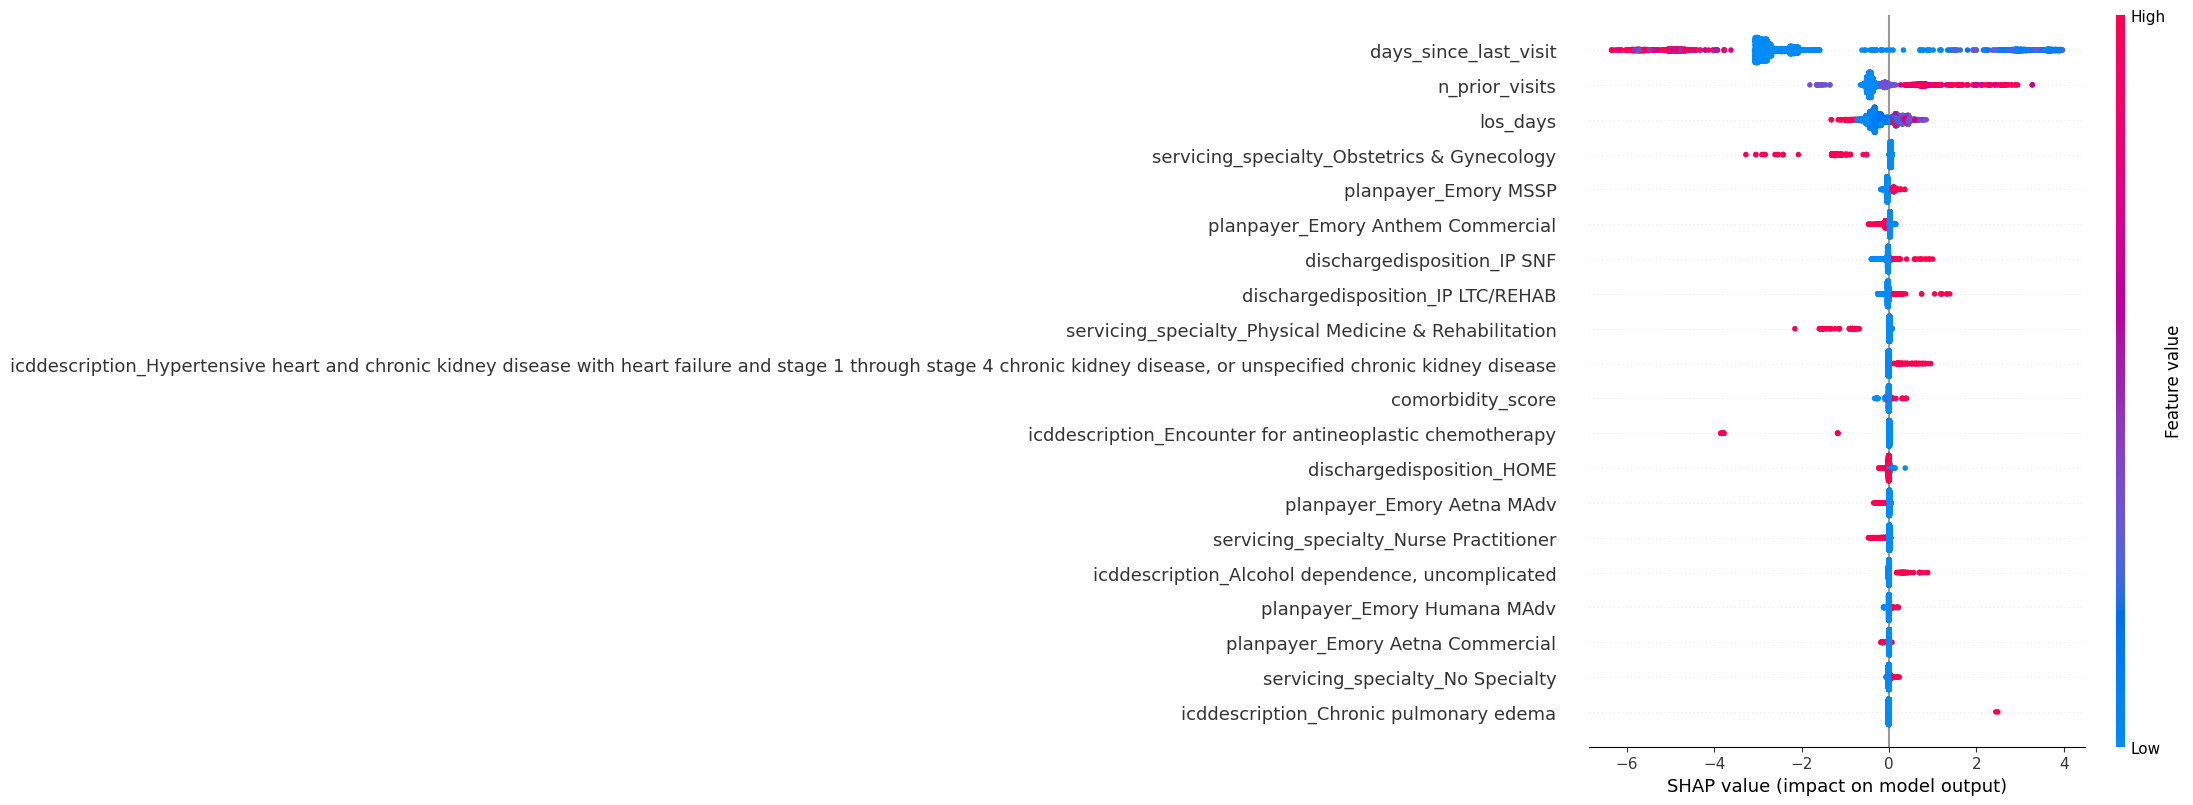

In [15]:
# --- 9. SHAP ---
import shap

# Extract the XGBoost model and transformed feature names from the pipeline
best_xgb    = search.best_estimator_.named_steps['clf']
preprocessor = search.best_estimator_.named_steps['prep']

# Get feature names after OHE
cat_feature_names = (
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(categorical_fts)
)
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_fts)])

# Transform test set
X_test_transformed = preprocessor.transform(X_test)

explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names,
    max_display=20,
)

SHAP values show how much each feature pushes the model's prediction 
toward or away from readmission. Red = high feature value, Blue = low.

### Top drivers of readmission risk

**days_since_last_visit** Patients readmitted shortly after discharge are at highest risk.
The longer the gap since the last hospitalization, the lower the risk.

**n_prior_visits** patients with more hospitalizations in their 
history are more likely to be readmitted. Frequent utilization 
could indicate underlying clinical instability.

**los_days** longer stays are associated with higher readmission risk, 
(likely more severe illness at admission).

### Place of Discharge (high-risk)
Patients discharged to Skilled Nursing Facilities (SNF) or 
Long-Term Care/Rehab facilities show elevated risk (complex cases).

### Low-risk
Obstetrics & Gynecology encounters reduce predicted risk 
(reflects planned maternity admissions which are typically short-term)

### Key takeaway
The two temporal features created for this phase 
`days_since_last_visit` and `n_prior_visits` are the strongest 
predictors. Their inclusion 
explains most of the improvement from ROC-AUC 0.949 to 0.983.


> Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting 
> model predictions. *NeurIPS*, 4768–4777. 
> https://arxiv.org/abs/1705.07874

## References

- Kansagara, D., Englander, H., Salanitro, A., Kagen, D., Theobald, C., 
  Freeman, M., & Kripalani, S. (2011). Risk prediction models for hospital 
  readmission: a systematic review. *JAMA, 306*(15), 1688–1698. 
  https://doi.org/10.1001/jama.2011.1515

- Zou, Q., Xie, S., Lin, Z., Wu, M., & Ju, Y. (2016). Finding the best 
  classification threshold in imbalanced classification. 
  *Big Data Research, 5*, 2–8. 
  https://doi.org/10.1016/j.bdr.2015.12.001

In [16]:
# --- Cross-validation --- 
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Logistic Regression', lr), 
                     ('Random Forest', rf), 
                     ('XGBoost', search.best_estimator_)]:
    scores = cross_validate(
        model, X, y,
        cv=cv,
        scoring=['roc_auc', 'average_precision'],
        n_jobs=-1
    )
    print(f"\n{name}")
    print(f"ROC-AUC : {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}")
    print(f"PR-AUC  : {scores['test_average_precision'].mean():.3f} ± {scores['test_average_precision'].std():.3f}")


Logistic Regression
ROC-AUC : 0.883 ± 0.005
PR-AUC  : 0.434 ± 0.030

Random Forest
ROC-AUC : 0.977 ± 0.007
PR-AUC  : 0.853 ± 0.018

XGBoost
ROC-AUC : 0.984 ± 0.003
PR-AUC  : 0.860 ± 0.012


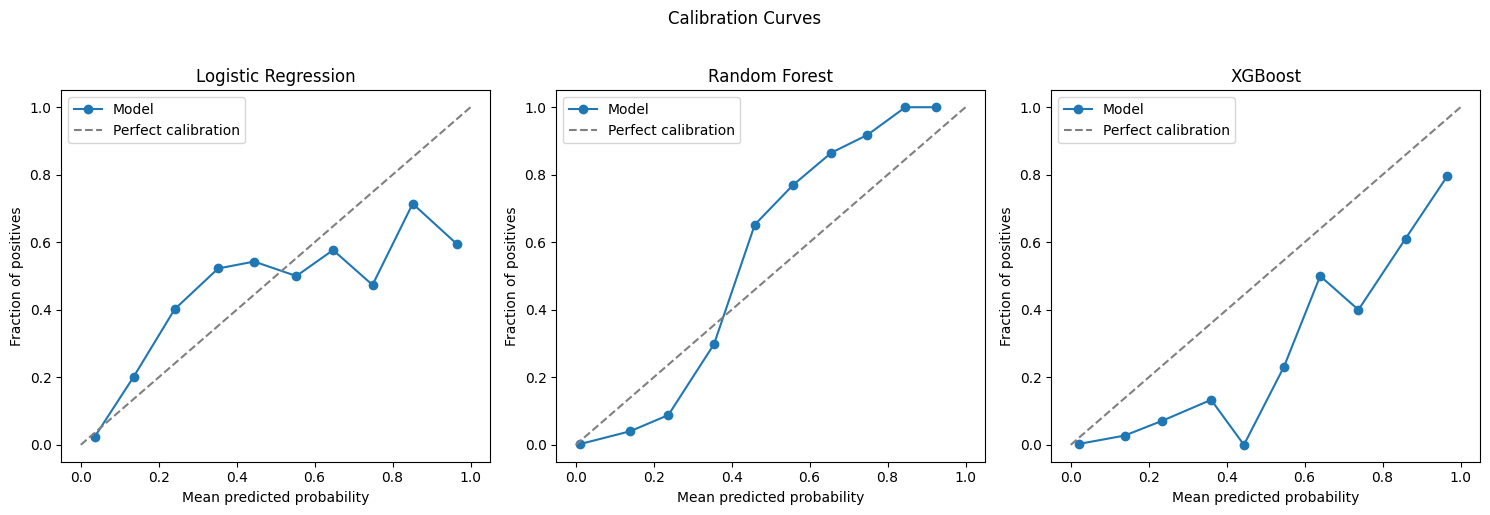

In [17]:
# --- Calibration ---
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, probs) in zip(axes, [
    ('Logistic Regression', probs_lr),
    ('Random Forest',       probs_rf),
    ('XGBoost',             probs_xgb)
]):
    fraction_of_positives, mean_predicted = calibration_curve(
        y_test, probs, n_bins=10
    )
    ax.plot(mean_predicted, fraction_of_positives, 
            marker='o', label='Model')
    ax.plot([0, 1], [0, 1], 
            linestyle='--', color='gray', label='Perfect calibration')
    ax.set_title(name)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend()

plt.suptitle('Calibration Curves', y=1.02)
plt.tight_layout()
plt.show()

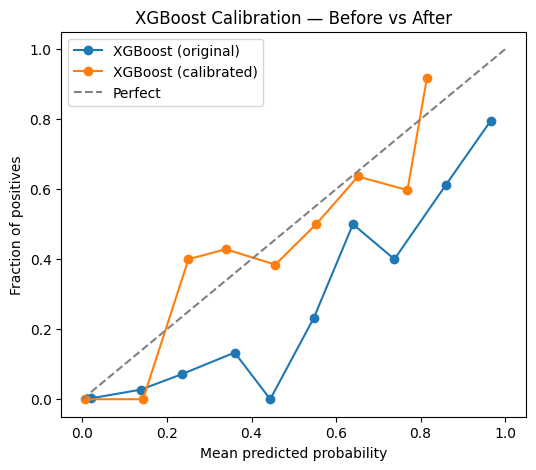

In [18]:
from sklearn.calibration import CalibratedClassifierCV

# XGBoost calibration
xgb_calibrated = CalibratedClassifierCV(
    search.best_estimator_, 
    cv=None,
    method='sigmoid'  
)
xgb_calibrated.fit(X_test, y_test)
probs_xgb_cal = xgb_calibrated.predict_proba(X_test)[:, 1]

#Plot
fraction_before, mean_before = calibration_curve(y_test, probs_xgb, n_bins=10)
fraction_after, mean_after   = calibration_curve(y_test, probs_xgb_cal, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(mean_before, fraction_before, marker='o', label='XGBoost (original)')
plt.plot(mean_after,  fraction_after,  marker='o', label='XGBoost (calibrated)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('XGBoost Calibration — Before vs After')
plt.legend()
plt.show()

All three models show miscalibration. Predicted probabilities do not 
accurately reflect true readmission rates, which is expected behavior 
for tree-based models (Niculescu-Mizil & Caruana, 2005).

Post-hoc calibration improves XGBoost's calibration 
in low probability ranges but remains imperfect, partly due to the 
limited size of the calibration set.

**Practical implication:** model probabilities should be interpreted 
as relative risk scores (higher = more risk) rather than absolute 
probabilities. A score of 0.80 does not reliably mean 80% chance 
of readmission.

So if the goal is to flag who needs attention first, the model works great. But if we need to say exactly how likely a patient is to come back, then more rigorous calibration would be needed.

### Recommendations for next cycles
More data is required for dedicated calibration.

## 9. Results Summary

### Model Comparison (visit level, optimized threshold)

| Model | ROC-AUC | PR-AUC | Precision | Recall | F1 | Threshold |
|-------|---------|--------|-----------|--------|----|-----------|
| *Phase 1 — LR (patient level)* | *0.949* | *0.638* | *0.61* | *0.55* | *0.58* | *0.20* |
| Logistic Regression | 0.889 | 0.451 | 0.44 | 0.59 | 0.51 | 0.15 |
| Random Forest | 0.981 | 0.882 | 0.81 | 0.89 | 0.85 | 0.40 |
| XGBoost | 0.983 | 0.860 | 0.78 | 0.94 | 0.86 | 0.65 |

### Cross-Validation

| Model | ROC-AUC | PR-AUC |
|-------|---------|--------|
| Logistic Regression | 0.883 ± 0.005 | 0.434 ± 0.030 |
| Random Forest | 0.977 ± 0.007 | 0.853 ± 0.018 |
| XGBoost | 0.984 ± 0.003 | 0.860 ± 0.012 |

Results are stable across folds, and no overfitting is detected.
XGBoost shows the lowest variance. However, all models show miscalibration.

### Key findings
- Visit-level framing significantly improves over patient-level baseline 
  across all models
- Temporal features (`days_since_last_visit`, `n_prior_visits`) are the 
  strongest predictors per SHAP (not available in Phase 1)
- XGBoost selected as final model: highest recall (0.94), capturing 94% 
  of actual readmissions
- Random Forest is a strong alternative when precision is prioritized

### Limitations
- We only have a single year of data available
- No external validation cohort
- SHAP explains the model, but does not show causality

## For phase 3

- [x] Add data from gt_op 
      (`n_op_visits`, `n_unique_op_dx`, etc. Consider that many ambulatory visits before an inpatient encounter may suggest a bad controlled chronic condition, and many op diagnoses count could indicate a complex case, so + risk and + cost)
- [x] Add chronic condition indicators from risks dataset
      (`chronicconditionasthmaind`, `chronicconditionhfind`, etc. Maybe we are missing dx detail/granularity after calculating Charlson)
- [x] Suggest sponsor a dedicated calibration set for reliable probability estimates (for next practicum cohort).